# Clasificación de Enfermedades en Hojas de Tomate
## Transfer Learning con ResNet50 — Dataset Local YOLO

**Dataset:** ~15,209 imágenes · 10 clases · Etiquetas en formato YOLO (bounding boxes)

| Clase | ID |
|-------|----|
| Tomato__BacterialSpot | 0 |
| Tomato__EarlyBlight | 1 |
| Tomato__Healthy | 2 |
| Tomato__LateBlight | 3 |
| Tomato__LeafMold | 4 |
| Tomato__MosaicVirus | 5 |
| Tomato__SeptoriaLeafSpot | 6 |
| Tomato__SpiderMites | 7 |
| Tomato__TargetSpot | 8 |
| Tomato__YellowLeafCurlVirus | 9 |

> Las etiquetas YOLO (class cx cy w h) se usan para clasificación extrayendo la clase mayoritaria de cada imagen.

## 1. Configuración e Imports

In [1]:
import os
import yaml
import random
import warnings
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from PIL import Image
from collections import Counter

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torch.amp import GradScaler, autocast
import torchvision.transforms as T
import torchvision.models as models
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, f1_score
from tqdm.auto import tqdm
import pandas as pd

warnings.filterwarnings('ignore')

# ── Reproducibilidad ──────────────────────────────────────────────────────────
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

# ── Hiperparámetros ───────────────────────────────────────────────────────────
DEVICE          = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
DATA_ROOT       = Path(r"C:\Users\jsire\Desktop\IA2\Tomtes-IA\data\tomato")
IMG_SIZE        = 224
BATCH_SIZE      = 64   # dataset más pequeño (~15k imágenes)
NUM_WORKERS     = 0    # 0 para evitar cuelgues en Windows/Jupyter
EPOCHS_FROZEN   = 5
EPOCHS_FINETUNE = 15
LR_FROZEN       = 1e-3
LR_FINETUNE     = 1e-4

print(f"Device : {DEVICE}")
if DEVICE.type == 'cuda':
    print(f"GPU    : {torch.cuda.get_device_name(0)}")
    print(f"VRAM   : {torch.cuda.get_device_properties(0).total_memory / 1024**3:.1f} GB")
else:
    print("GPU    : no disponible — se usará CPU (entrenamiento lento)")
print(f"PyTorch: {torch.__version__}")

Device : cuda
GPU    : NVIDIA GeForce RTX 5080
VRAM   : 15.9 GB
PyTorch: 2.11.0+cu128


C:\Users\jsire\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 2. Análisis Exploratorio del Dataset (EDA)

In [2]:
# Inspección del dataset local
with open(DATA_ROOT / 'data.yaml') as f:
    cfg = yaml.safe_load(f)

n_images = len(list((DATA_ROOT / 'images').glob('*.jpg'))) + \
           len(list((DATA_ROOT / 'images').glob('*.jpeg'))) + \
           len(list((DATA_ROOT / 'images').glob('*.png')))
n_labels = len(list((DATA_ROOT / 'labels').glob('*.txt')))

print(f"Ruta     : {DATA_ROOT}")
print(f"Clases   : {cfg['nc']}")
print(f"Imágenes : {n_images:,}")
print(f"Labels   : {n_labels:,}")
print()
print("Clases definidas en data.yaml:")
for i, name in enumerate(cfg['names']):
    print(f"  {i}: {name}")

Ruta     : C:\Users\jsire\Desktop\IA2\Tomtes-IA\data\tomato
Clases   : 10
Imágenes : 15,209
Labels   : 15,209

Clases definidas en data.yaml:
  0: Tomato__BacterialSpot
  1: Tomato__EarlyBlight
  2: Tomato__Healthy
  3: Tomato__LateBlight
  4: Tomato__LeafMold
  5: Tomato__MosaicVirus
  6: Tomato__SeptoriaLeafSpot
  7: Tomato__SpiderMites
  8: Tomato__TargetSpot
  9: Tomato__YellowLeafCurlVirus


In [3]:
def collect_samples(root: Path):
    """
    Lee el dataset en formato YOLO (images/ + labels/).
    Cada archivo .txt tiene líneas 'class_id cx cy w h'.
    Para clasificación se usa la clase mayoritaria del archivo de etiquetas.
    """
    images_dir = root / 'images'
    labels_dir = root / 'labels'

    with open(root / 'data.yaml') as f:
        cfg = yaml.safe_load(f)
    classes = cfg['names']
    class_to_idx = {cls: i for i, cls in enumerate(classes)}

    samples = []
    for img_path in sorted(images_dir.iterdir()):
        if img_path.suffix.lower() not in ('.jpg', '.jpeg', '.png'):
            continue
        label_path = labels_dir / (img_path.stem + '.txt')
        if not label_path.exists():
            continue
        lines = label_path.read_text().strip().splitlines()
        if not lines:
            continue
        class_ids = [int(line.split()[0]) for line in lines if line.strip()]
        label = Counter(class_ids).most_common(1)[0][0]
        samples.append((str(img_path), label))

    return samples, classes, class_to_idx

samples, classes, class_to_idx = collect_samples(DATA_ROOT)
idx_to_class = {v: k for k, v in class_to_idx.items()}
class_names  = [c.replace('Tomato__', '').replace('_', ' ') for c in classes]

print(f"Total imágenes : {len(samples):,}")
print(f"Clases         : {len(classes)}")
print()
labels = [s[1] for s in samples]
counts = Counter(labels)
df_dist = pd.DataFrame({'Clase': class_names, 'Imágenes': [counts[i] for i in range(len(classes))]})
df_dist['%'] = (df_dist['Imágenes'] / df_dist['Imágenes'].sum() * 100).round(1)
print(df_dist.to_string(index=False))

Total imágenes : 15,209
Clases         : 10

              Clase  Imágenes    %
      BacterialSpot      2001 13.2
        EarlyBlight      1086  7.1
            Healthy      1654 10.9
         LateBlight      1999 13.1
           LeafMold      1042  6.9
        MosaicVirus       428  2.8
   SeptoriaLeafSpot      1919 12.6
        SpiderMites      1676 11.0
         TargetSpot      1404  9.2
YellowLeafCurlVirus      2000 13.2


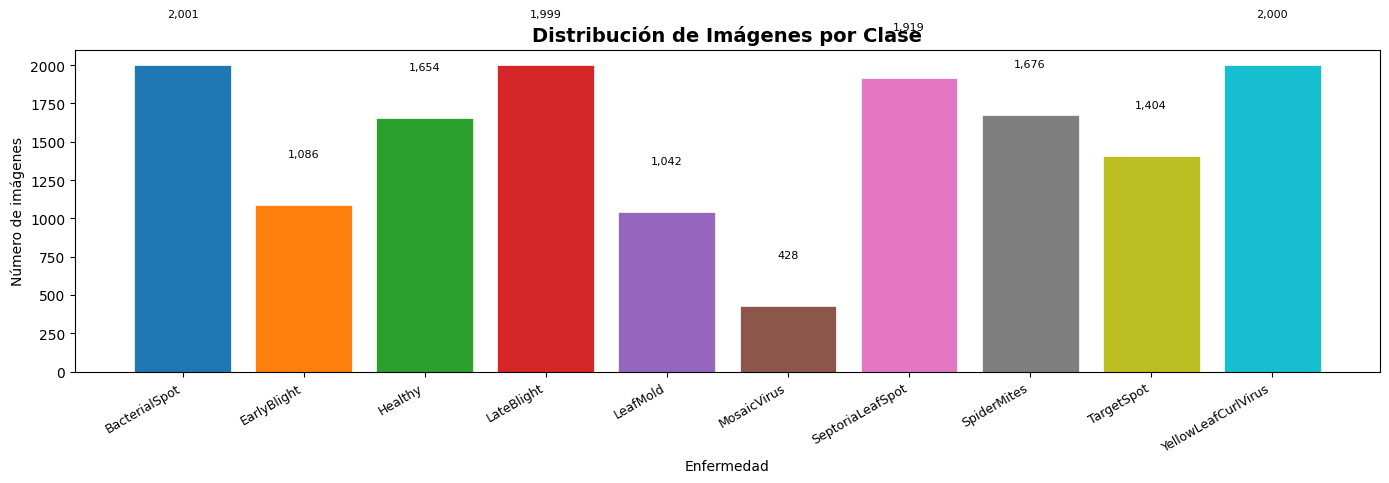

Ratio desbalance (max/min): 4.7x


In [4]:
# ── Distribución por clase ─────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 5))
colors = plt.cm.tab10(np.linspace(0, 1, len(classes)))
bar_vals = [counts[i] for i in range(len(classes))]
bars = ax.bar(class_names, bar_vals, color=colors, edgecolor='white', linewidth=0.5)
ax.set_title('Distribución de Imágenes por Clase', fontsize=14, fontweight='bold')
ax.set_xlabel('Enfermedad')
ax.set_ylabel('Número de imágenes')
plt.xticks(rotation=30, ha='right', fontsize=9)
for bar, val in zip(bars, bar_vals):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 300,
            f'{val:,}', ha='center', va='bottom', fontsize=8)
plt.tight_layout()
plt.savefig('distribucion_clases.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"Ratio desbalance (max/min): {max(bar_vals)/min(bar_vals):.1f}x")

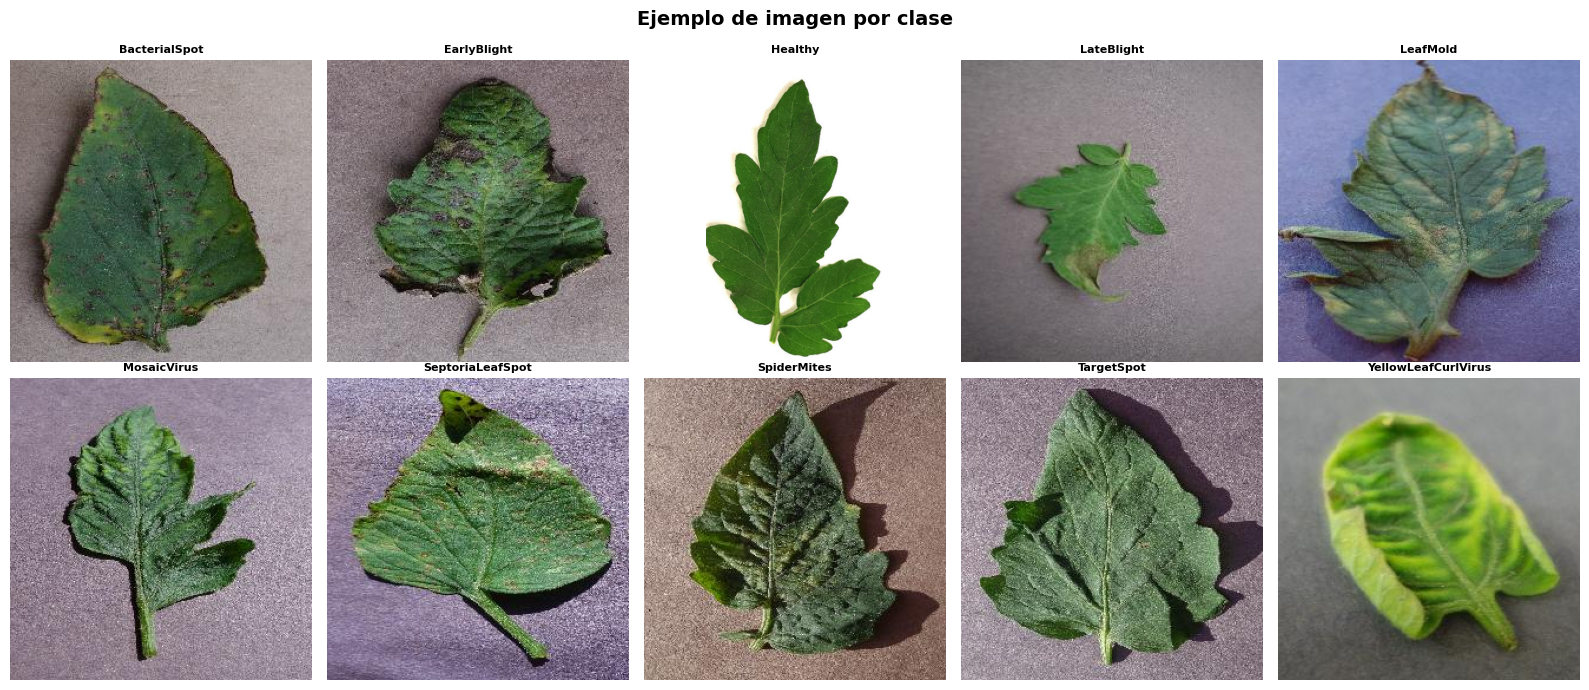

In [5]:
# ── Muestras visuales de cada clase ───────────────────────────────────────────
fig, axes = plt.subplots(2, 5, figsize=(16, 7))
axes = axes.flatten()
for i in range(len(classes)):
    cls_samples = [s[0] for s in samples if s[1] == i]
    img = Image.open(random.choice(cls_samples)).convert('RGB')
    axes[i].imshow(img)
    axes[i].set_title(class_names[i], fontsize=8, fontweight='bold')
    axes[i].axis('off')
plt.suptitle('Ejemplo de imagen por clase', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('muestras_clases.png', dpi=150, bbox_inches='tight')
plt.show()

## 3. Preprocesamiento y División del Dataset

In [6]:
# ── Split estratificado 70 / 15 / 15 ──────────────────────────────────────────
# Nota: hacemos split a nivel de imagen augmentada (no original) para simplificar.
# En producción se splitearía por imagen original para evitar data leakage.
train_samples, temp = train_test_split(
    samples, test_size=0.30, stratify=labels, random_state=SEED
)
temp_labels = [s[1] for s in temp]
val_samples, test_samples = train_test_split(
    temp, test_size=0.50, stratify=temp_labels, random_state=SEED
)

print(f"Train : {len(train_samples):>7,} imágenes ({len(train_samples)/len(samples)*100:.0f}%)")
print(f"Val   : {len(val_samples):>7,} imágenes ({len(val_samples)/len(samples)*100:.0f}%)")
print(f"Test  : {len(test_samples):>7,} imágenes ({len(test_samples)/len(samples)*100:.0f}%)")

Train :  10,646 imágenes (70%)
Val   :   2,281 imágenes (15%)
Test  :   2,282 imágenes (15%)


In [7]:
# ── Transforms ────────────────────────────────────────────────────────────────
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

train_tf = T.Compose([
    T.Resize((IMG_SIZE + 32, IMG_SIZE + 32)),
    T.RandomCrop(IMG_SIZE),
    T.RandomHorizontalFlip(),
    T.RandomRotation(15),
    T.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.05),
    T.ToTensor(),
    T.Normalize(IMAGENET_MEAN, IMAGENET_STD)
])

eval_tf = T.Compose([
    T.Resize((IMG_SIZE, IMG_SIZE)),
    T.ToTensor(),
    T.Normalize(IMAGENET_MEAN, IMAGENET_STD)
])


class TomatoDataset(Dataset):
    def __init__(self, samples, transform=None):
        self.samples   = samples
        self.transform = transform

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        path, label = self.samples[idx]
        image = Image.open(path).convert('RGB')
        if self.transform:
            image = self.transform(image)
        return image, label


train_ds = TomatoDataset(train_samples, train_tf)
val_ds   = TomatoDataset(val_samples,   eval_tf)
test_ds  = TomatoDataset(test_samples,  eval_tf)

# WeightedRandomSampler para compensar el desbalance de clases
train_labels   = [s[1] for s in train_samples]
class_counts   = Counter(train_labels)
sample_weights = [1.0 / class_counts[lbl] for lbl in train_labels]
sampler = WeightedRandomSampler(sample_weights, num_samples=len(sample_weights), replacement=True)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, sampler=sampler,
                          num_workers=NUM_WORKERS, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=NUM_WORKERS, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=NUM_WORKERS, pin_memory=True)

print(f"Batches/época: train={len(train_loader)} | val={len(val_loader)} | test={len(test_loader)}")

Batches/época: train=167 | val=36 | test=36


## 4. Modelo — ResNet50 con Transfer Learning

In [8]:
def build_model(num_classes: int, freeze_backbone: bool = True) -> nn.Module:
    model = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V2)
    if freeze_backbone:
        for param in model.parameters():
            param.requires_grad = False
    model.fc = nn.Sequential(
        nn.Dropout(p=0.3),
        nn.Linear(model.fc.in_features, num_classes)
    )
    return model

model = build_model(num_classes=len(classes), freeze_backbone=True).to(DEVICE)

# Pesos de clase para la función de pérdida (maneja desbalance)
class_weights = torch.tensor(
    [1.0 / class_counts[i] for i in range(len(classes))], dtype=torch.float32
)
class_weights = (class_weights / class_weights.sum() * len(classes)).to(DEVICE)
criterion = nn.CrossEntropyLoss(weight=class_weights)

total_params     = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Parámetros totales     : {total_params:,}")
print(f"Parámetros entrenables : {trainable_params:,}  ({trainable_params/total_params*100:.1f}%)")

Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to C:\Users\jsire/.cache\torch\hub\checkpoints\resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 103MB/s] 


Parámetros totales     : 23,528,522
Parámetros entrenables : 20,490  (0.1%)


## 5. Entrenamiento

In [9]:
def train_epoch(model, loader, criterion, optimizer, scaler):
    model.train()
    total_loss, correct, total = 0.0, 0, 0
    pbar = tqdm(loader, desc='  Train', leave=False)
    for images, labels in pbar:
        images, labels = images.to(DEVICE), labels.to(DEVICE)
        optimizer.zero_grad()
        with autocast(device_type='cuda'):
            outputs = model(images)
            loss    = criterion(outputs, labels)
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()
        total_loss += loss.item() * images.size(0)
        correct    += outputs.argmax(1).eq(labels).sum().item()
        total      += images.size(0)
        pbar.set_postfix(loss=f'{loss.item():.3f}', acc=f'{100.*correct/total:.1f}%')
    return total_loss / total, 100. * correct / total


@torch.no_grad()
def eval_epoch(model, loader, criterion):
    model.eval()
    total_loss, correct, total = 0.0, 0, 0
    all_preds, all_labels = [], []
    for images, labels in tqdm(loader, desc='  Val  ', leave=False):
        images, labels = images.to(DEVICE), labels.to(DEVICE)
        with autocast(device_type='cuda'):
            outputs = model(images)
            loss    = criterion(outputs, labels)
        total_loss += loss.item() * images.size(0)
        preds = outputs.argmax(1)
        correct += preds.eq(labels).sum().item()
        total   += images.size(0)
        all_preds.extend(preds.cpu().tolist())
        all_labels.extend(labels.cpu().tolist())
    f1 = f1_score(all_labels, all_preds, average='macro', zero_division=0)
    return total_loss / total, 100. * correct / total, f1


history = {k: [] for k in ('train_loss','val_loss','train_acc','val_acc','val_f1')}
best_val_acc = 0.0
scaler = GradScaler(device='cuda')

In [10]:
# ── FASE 1: Solo se entrena la cabeza (backbone congelado) ────────────────────
print("=" * 60)
print("FASE 1 — Cabeza clasificadora (backbone congelado)")
print("=" * 60)

optimizer = optim.AdamW(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=LR_FROZEN, weight_decay=1e-4
)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS_FROZEN)

for epoch in range(1, EPOCHS_FROZEN + 1):
    tr_loss, tr_acc          = train_epoch(model, train_loader, criterion, optimizer, scaler)
    vl_loss, vl_acc, vl_f1   = eval_epoch(model, val_loader, criterion)
    scheduler.step()
    for k, v in zip(history, [tr_loss, vl_loss, tr_acc, vl_acc, vl_f1]):
        history[k].append(v)
    marker = ''
    if vl_acc > best_val_acc:
        best_val_acc = vl_acc
        torch.save(model.state_dict(), 'best_model.pth')
        marker = '  ← guardado'
    print(f"  Época {epoch:02d}/{EPOCHS_FROZEN} | "
          f"Loss {tr_loss:.4f}/{vl_loss:.4f} | "
          f"Acc {tr_acc:.1f}%/{vl_acc:.1f}% | "
          f"F1 {vl_f1:.4f}{marker}")

FASE 1 — Cabeza clasificadora (backbone congelado)


  Época 01/5 | Loss 1.3010/1.3122 | Acc 52.6%/52.1% | F1 0.5340  ← guardado


  Época 02/5 | Loss 0.7727/0.9990 | Acc 75.4%/65.6% | F1 0.6478  ← guardado


  Época 03/5 | Loss 0.6339/0.8434 | Acc 79.6%/72.2% | F1 0.7028  ← guardado


  Época 04/5 | Loss 0.5924/0.8543 | Acc 81.1%/70.3% | F1 0.6897


  Época 05/5 | Loss 0.5569/0.8186 | Acc 81.9%/71.1% | F1 0.6969


In [11]:
# ── FASE 2: Fine-tuning completo ──────────────────────────────────────────────
print("=" * 60)
print("FASE 2 — Fine-tuning (todas las capas desbloqueadas)")
print("=" * 60)

for param in model.parameters():
    param.requires_grad = True

# Discriminative learning rates: backbone más lento que la cabeza
backbone_params = list(model.parameters())[:-2]
head_params     = list(model.parameters())[-2:]
optimizer = optim.AdamW([
    {'params': backbone_params, 'lr': LR_FINETUNE / 10},
    {'params': head_params,     'lr': LR_FINETUNE}
], weight_decay=1e-4)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS_FINETUNE)

for epoch in range(1, EPOCHS_FINETUNE + 1):
    tr_loss, tr_acc          = train_epoch(model, train_loader, criterion, optimizer, scaler)
    vl_loss, vl_acc, vl_f1   = eval_epoch(model, val_loader, criterion)
    scheduler.step()
    for k, v in zip(history, [tr_loss, vl_loss, tr_acc, vl_acc, vl_f1]):
        history[k].append(v)
    marker = ''
    if vl_acc > best_val_acc:
        best_val_acc = vl_acc
        torch.save(model.state_dict(), 'best_model.pth')
        marker = '  ← guardado'
    print(f"  Época {epoch:02d}/{EPOCHS_FINETUNE} | "
          f"Loss {tr_loss:.4f}/{vl_loss:.4f} | "
          f"Acc {tr_acc:.1f}%/{vl_acc:.1f}% | "
          f"F1 {vl_f1:.4f}{marker}")

print(f"\nMejor Val Accuracy: {best_val_acc:.2f}%")

FASE 2 — Fine-tuning (todas las capas desbloqueadas)


  Época 01/15 | Loss 0.4195/0.5457 | Acc 85.1%/80.4% | F1 0.7814  ← guardado


  Época 02/15 | Loss 0.2888/0.4187 | Acc 89.5%/85.3% | F1 0.8340  ← guardado


  Época 03/15 | Loss 0.2409/0.3611 | Acc 91.2%/87.5% | F1 0.8582  ← guardado


  Época 04/15 | Loss 0.2068/0.3310 | Acc 92.1%/87.6% | F1 0.8594  ← guardado


...

  Época 11/15 | Loss 0.1105/0.2228 | Acc 95.5%/92.3% | F1 0.9116  ← guardado


  Época 12/15 | Loss 0.1023/0.2111 | Acc 95.8%/92.4% | F1 0.9122  ← guardado


  Época 13/15 | Loss 0.1072/0.2200 | Acc 95.5%/91.9% | F1 0.9084


  Época 14/15 | Loss 0.1111/0.2141 | Acc 95.4%/92.5% | F1 0.9167  ← guardado


  Época 15/15 | Loss 0.0984/0.2082 | Acc 96.1%/93.1% | F1 0.9210  ← guardado

Mejor Val Accuracy: 93.07%


## 6. Curvas de Entrenamiento

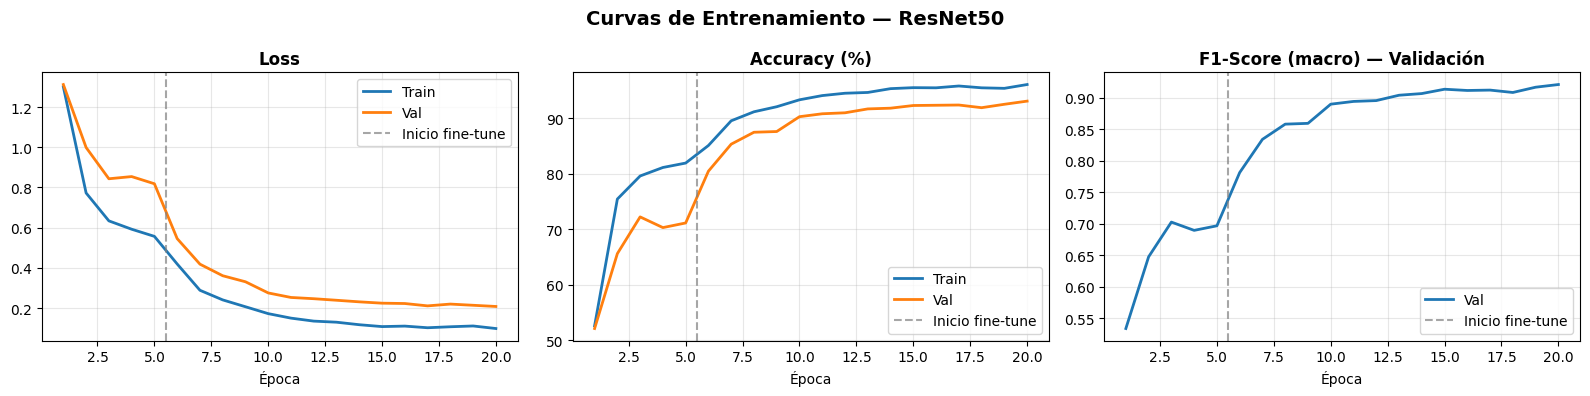

In [12]:
epochs = range(1, len(history['train_loss']) + 1)
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

for ax, (train_key, val_key), title in zip(
    axes,
    [('train_loss','val_loss'), ('train_acc','val_acc'), (None,'val_f1')],
    ['Loss', 'Accuracy (%)', 'F1-Score (macro) — Validación']
):
    if train_key:
        ax.plot(epochs, history[train_key], label='Train', linewidth=2)
    ax.plot(epochs, history[val_key], label='Val', linewidth=2)
    ax.axvline(x=EPOCHS_FROZEN + 0.5, color='gray', linestyle='--', alpha=0.7, label='Inicio fine-tune')
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel('Época')
    ax.legend()
    ax.grid(alpha=0.3)

plt.suptitle('Curvas de Entrenamiento — ResNet50', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('training_curves.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Evaluación sobre el Conjunto de Test

In [13]:
# Cargar el mejor modelo guardado
model.load_state_dict(torch.load('best_model.pth', map_location=DEVICE))
model.eval()

all_preds, all_labels = [], []
with torch.no_grad():
    for images, labels in tqdm(test_loader, desc='Evaluando test'):
        images = images.to(DEVICE)
        with autocast(device_type='cuda'):
            outputs = model(images)
        all_preds.extend(outputs.argmax(1).cpu().tolist())
        all_labels.extend(labels.tolist())

test_acc = sum(p == l for p, l in zip(all_preds, all_labels)) / len(all_labels) * 100
test_f1  = f1_score(all_labels, all_preds, average='macro', zero_division=0)

print(f"Test Accuracy : {test_acc:.2f}%")
print(f"Test F1 macro : {test_f1:.4f}")
print()
print(classification_report(all_labels, all_preds, target_names=class_names, zero_division=0))

Evaluando test: 100%|██████████| 36/36 [00:10<00:00,  3.46it/s]

Test Accuracy : 92.81%
Test F1 macro : 0.9190

                     precision    recall  f1-score   support

      BacterialSpot       0.97      0.88      0.92       300
        EarlyBlight       0.86      0.94      0.90       163
            Healthy       0.97      0.90      0.93       248
         LateBlight       0.96      0.90      0.93       300
           LeafMold       0.90      0.94      0.92       156
        MosaicVirus       0.74      0.97      0.84        64
   SeptoriaLeafSpot       0.94      0.95      0.94       288
        SpiderMites       0.88      0.98      0.93       252
         TargetSpot       0.89      0.90      0.90       211
YellowLeafCurlVirus       0.99      0.96      0.97       300

           accuracy                           0.93      2282
          macro avg       0.91      0.93      0.92      2282
       weighted avg       0.93      0.93      0.93      2282



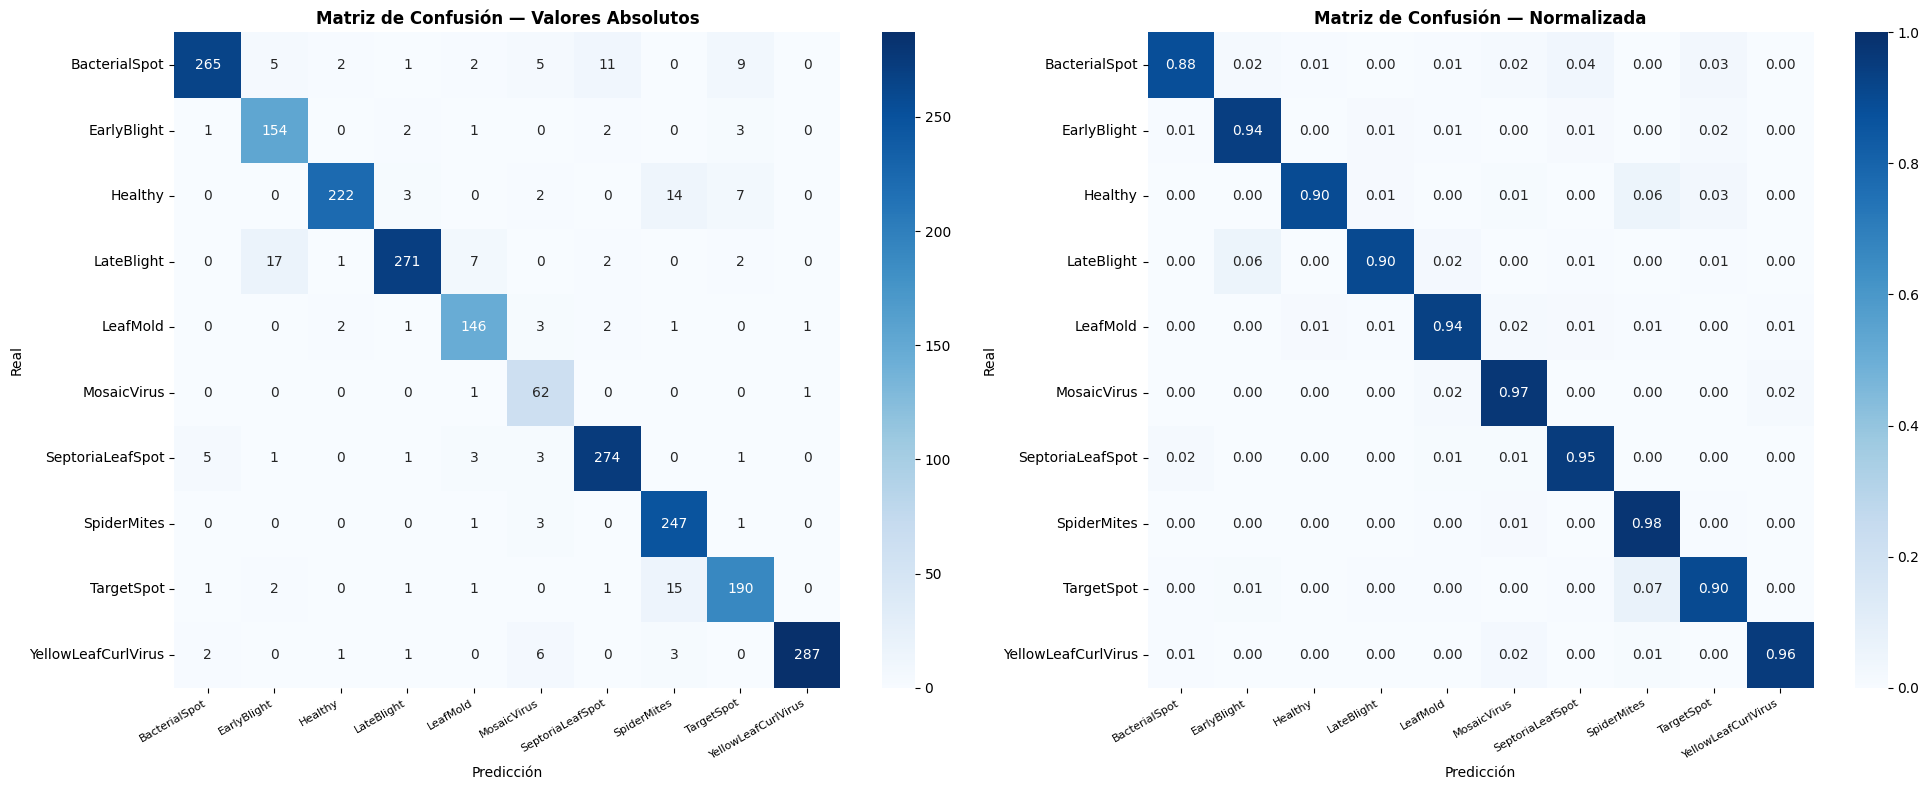

In [14]:
# ── Matriz de confusión ────────────────────────────────────────────────────────
cm = confusion_matrix(all_labels, all_preds)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

fig, axes = plt.subplots(1, 2, figsize=(20, 8))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names, ax=axes[0])
axes[0].set_title('Matriz de Confusión — Valores Absolutos', fontweight='bold')
axes[0].set_xlabel('Predicción')
axes[0].set_ylabel('Real')
plt.setp(axes[0].get_xticklabels(), rotation=30, ha='right', fontsize=8)

sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names, ax=axes[1],
            vmin=0, vmax=1)
axes[1].set_title('Matriz de Confusión — Normalizada', fontweight='bold')
axes[1].set_xlabel('Predicción')
axes[1].set_ylabel('Real')
plt.setp(axes[1].get_xticklabels(), rotation=30, ha='right', fontsize=8)

plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

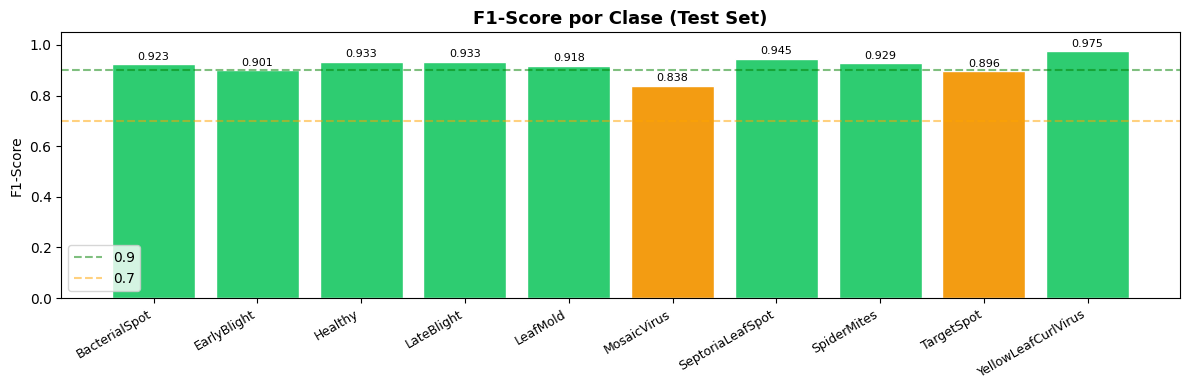

In [15]:
# ── F1-score por clase ─────────────────────────────────────────────────────────
f1_per_class = f1_score(all_labels, all_preds, average=None, zero_division=0)

fig, ax = plt.subplots(figsize=(12, 4))
colors = ['#2ecc71' if f >= 0.9 else '#f39c12' if f >= 0.7 else '#e74c3c' for f in f1_per_class]
bars = ax.bar(class_names, f1_per_class, color=colors, edgecolor='white')
ax.set_title('F1-Score por Clase (Test Set)', fontsize=13, fontweight='bold')
ax.set_ylim(0, 1.05)
ax.axhline(y=0.9, color='green', linestyle='--', alpha=0.5, label='0.9')
ax.axhline(y=0.7, color='orange', linestyle='--', alpha=0.5, label='0.7')
ax.legend()
ax.set_ylabel('F1-Score')
plt.xticks(rotation=30, ha='right', fontsize=9)
for bar, val in zip(bars, f1_per_class):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{val:.3f}', ha='center', va='bottom', fontsize=8)
plt.tight_layout()
plt.savefig('f1_por_clase.png', dpi=150, bbox_inches='tight')
plt.show()

## 8. Análisis de Errores — Predicciones Incorrectas

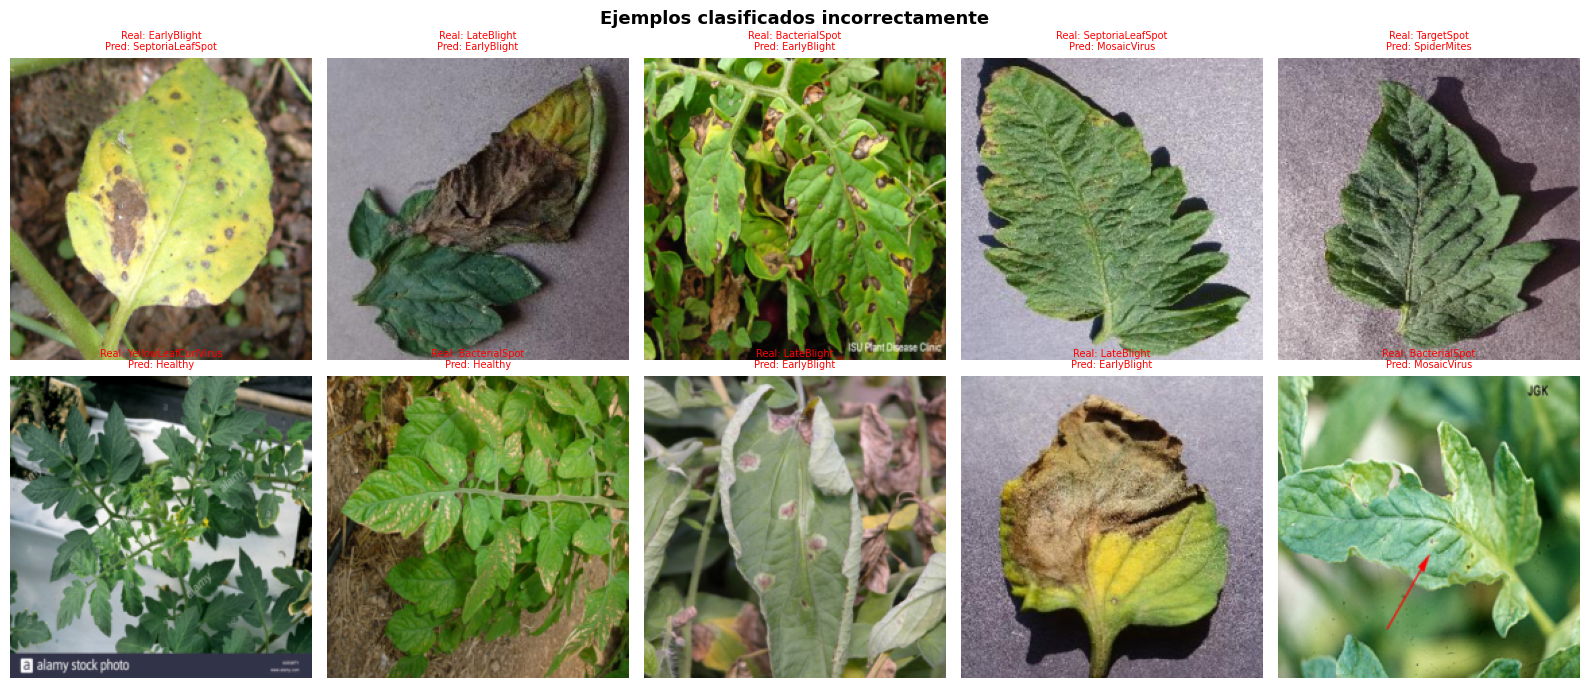

In [16]:
MEAN = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
STD  = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)

def denormalize(tensor):
    return (tensor * STD + MEAN).clamp(0, 1).permute(1, 2, 0).numpy()

misclassified = []
model.eval()
loader_shuffle = DataLoader(test_ds, batch_size=64, shuffle=True, num_workers=NUM_WORKERS)

with torch.no_grad():
    for images, labels in loader_shuffle:
        with autocast(device_type='cuda'):
            preds = model(images.to(DEVICE)).argmax(1).cpu()
        wrong = (preds != labels).nonzero(as_tuple=True)[0]
        for i in wrong:
            misclassified.append((images[i], labels[i].item(), preds[i].item()))
        if len(misclassified) >= 10:
            break

fig, axes = plt.subplots(2, 5, figsize=(16, 7))
for ax, (img, true, pred) in zip(axes.flatten(), misclassified[:10]):
    ax.imshow(denormalize(img))
    ax.set_title(f'Real: {class_names[true]}\nPred: {class_names[pred]}',
                 fontsize=7, color='red')
    ax.axis('off')
plt.suptitle('Ejemplos clasificados incorrectamente', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('misclassified.png', dpi=150, bbox_inches='tight')
plt.show()

## 9. Resumen Final

| Métrica | Valor |
|---------|-------|
| Modelo | ResNet50 (ImageNet pretrained) |
| Dataset | ~15,209 imágenes locales (formato YOLO) |
| Épocas | 5 (frozen) + 15 (fine-tune) |
| Batch size | 64 |
| Optimizador | AdamW + CosineAnnealingLR |
| Mixed Precision | FP16 (torch.amp) |
| Manejo desbalance | WeightedRandomSampler + class_weights en loss |

In [17]:
print("="*50)
print("RESULTADOS FINALES")
print("="*50)
print(f"Mejor Val Accuracy : {best_val_acc:.2f}%")
print(f"Test Accuracy      : {test_acc:.2f}%")
print(f"Test F1 (macro)    : {test_f1:.4f}")
print()
print("Archivos guardados:")
print("  best_model.pth        — pesos del mejor modelo")
print("  training_curves.png   — curvas de entrenamiento")
print("  confusion_matrix.png  — matriz de confusión")
print("  f1_por_clase.png      — F1 por clase")
print("  misclassified.png     — ejemplos de errores")

RESULTADOS FINALES
Mejor Val Accuracy : 93.07%
Test Accuracy      : 92.81%
Test F1 (macro)    : 0.9190

Archivos guardados:
  best_model.pth        — pesos del mejor modelo
  training_curves.png   — curvas de entrenamiento
  confusion_matrix.png  — matriz de confusión
  f1_por_clase.png      — F1 por clase
  misclassified.png     — ejemplos de errores
